**MNIST Digit Classification Neural Network Project**

The MNIST Digit Classification Project is a Supervised Machine Learning and Deep Learning project where the goal is to identify the digits 0-9 from images using the Neural Network.

Each image is  

28 x 28 pixels

grayscale

Represnts a single digit (0-9)

The project objective is:

1.Train a neural network that learn patterns from handwriten digits

2.Predict the digit shown in new and unseen image.  

3.Evaluate the performance using the accuracy and loss.

MNSIT besically refers to the Modified National Institute of Standards and Technology.  

Basically NIST is a US organization  that originally created a dataset of handwritten digits. Scientists later modifed and cleaned the datset to make it easier for the machine learning research.

Steps in the project include:

1. Loading the dataset.  
2. Normalize the pixel values.
3. Convert the labels to categorical form
4. Build neural network.
5. Train Model
6. Evalueate the accuraccy
7. Make predictions

In MNIST Digit Classification, the neural network used is the Artificial Neural Network (ANN).  

ANN specially feeds a Feed Forward Neural Network also called a Multilayer Perceptron.

**Structure of the Network**

The model looks like this:

1.Input layer: It takes images of size 28 x 28. Flatten converts it into 784 pixels.

2.Hidden Layers (Learning Layers):

Dense layer 1: 128 neurons, Activation Relu and learns basic digit patterns.

Dense Layer 2: 64 neurons and learns deeper features.  

3.Output Layer: 10 neurons has digits 0-9 and activation of Softmax and it outputs the probabilities.


Also one more thing to note is that that MNISt dataset is already pre defined dataset that is already split by default into the training and test sets. Hence, we do not need to split it manually.

In [22]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [23]:
# Loading the data into train adntest splits

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [24]:
x_train
# data on which the model is trained

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [25]:
x_test
# Data on which the model is tested

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [26]:
y_train
# data on which model is trained

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [27]:
y_test
# data on which the model is tested

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

Now, comes the part of the normalization of the data as normalization helps in faster and stable training.

In [28]:
x_train = x_train/255.0
x_test = x_test/255.0

No, we will be performing the One Hot label encoding and it is done that how the neural network outputs the predictions.

In [29]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [30]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [31]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [32]:
# Now, we will be building the neural network model as:
from keras.models import Sequential
from keras.layers import Dense, Flatten

model = Sequential()
model.add(Flatten(input_shape = (28,28)))
model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<Sequential name=sequential_3, built=True>

In [33]:
model.add(Dense(128, activation = 'relu'))
model

<Sequential name=sequential_3, built=True>

In [34]:
model.add(Dense(64, activation = 'relu'))
model

<Sequential name=sequential_3, built=True>

In [35]:
model.add(Dense(10, activation = 'softmax'))
model

<Sequential name=sequential_3, built=True>

Layers

In keras, we have layers which is a building block of a neural network. Each layer performs a specific transformation on the input data and passes the result to the next layer.

In [44]:
# Now, we will be compiling the model for the further pre processing

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model

<Sequential name=sequential_3, built=True>

Flatten : Converts the 28x28 image into 784 values

Dense(128) : Learns the image patterns.

Dense(64) : Extracts deeper features

Dense(10) : Outputs the probability  for 0-9 numbers

**Meaning of the Input Features**

Adam: Fast and adaptive customizer

Categorical crossentropy : Best for the multi class classification

Accuracy: It measures the correct predictions


In [46]:
history = model.fit(x_train, y_train,epochs=10,batch_size=32,validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9758 - val_loss: 0.1115
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9755 - val_loss: 0.1262
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9950 - loss: 0.0131 - val_accuracy: 0.9761 - val_loss: 0.1120
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9965 - loss: 0.0100 - val_accuracy: 0.9764 - val_loss: 0.1208
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9771 - val_loss: 0.1219
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9768 - val_loss: 0.1285
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9973 - loss: 0.0080 - val_accuracy: 0.9750 - val_loss: 0.1397
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9967 - loss: 0.0103 -

In [47]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy: ", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9754 - loss: 0.1429
Test Accuracy:  0.9789999723434448


Hence the test accuracy is around 97.8%

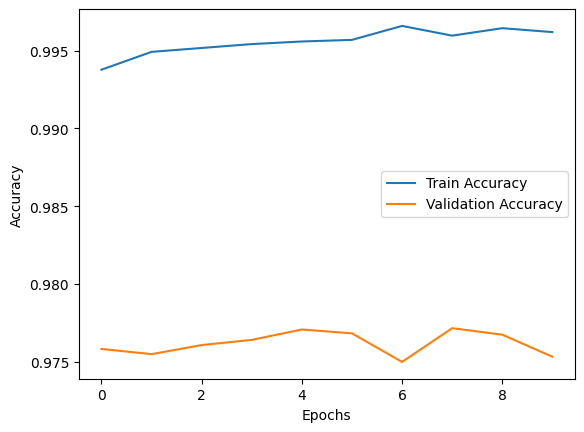

In [50]:
# We wwill be plotting the training performance

plt.plot(history.history['accuracy'], label = "Train Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

From this graph, we can infer that the model is learning well. The training accuracy increases steadily from 99.4% to 99.7%. This means that the neural network is learning well from the patterns.

it also shows that the model performs ell on train data than unseen data.

In [51]:
# Predicting a digit
prediction = model.predict(x_test[0].reshape(1,28,28))

print("Predicted Digit: ", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Predicted Digit:  7


In [53]:
# Making more predictions

predictions = model.predict(x_test[:10])
predicted_digits = predictions.argmax(axis   = 1)

print(predicted_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[7 2 1 0 4 1 4 9 5 9]


Plotting of the Confusion Matrix

In [54]:
import numpy as np
predictions = model.predict(x_test)

y_pred = predictions.argmax(axis = 1)

y_true = y_test.argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


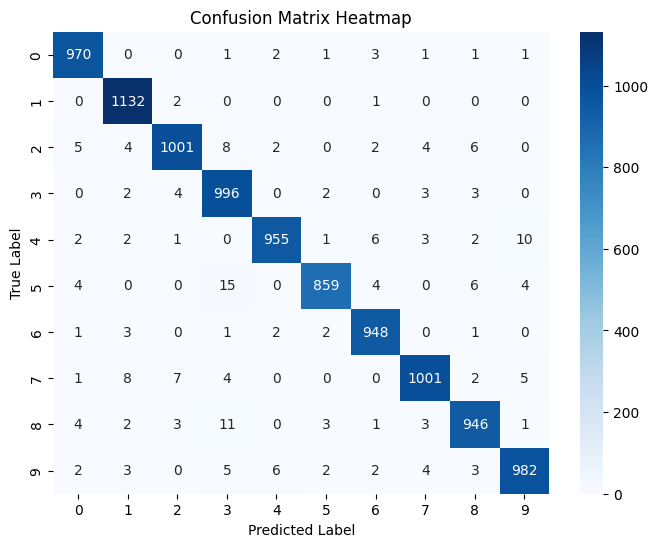

In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()